In [24]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import re
import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Optional, Tuple, Union
import pandas as pd

#from typing import Any, Dict, List, Union


from tqdm import tqdm
import json

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle
#from thesis_project.training.key_word_spotting.train_base_loop import fit_base_model, validate_model
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg

MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/"
MODEL_CHECKPOINT = MODEL_DIR + "best_model.pth"
MODEL_HISTORY = np.load(MODEL_DIR + "history.npy", allow_pickle=True).item()
BATCH_SIZE = 64
DO_SWEEP = False
DO_FULL_AND_30 = True
STEP_FOR_RANK_SWEP_EVAL = 1
VAL_SNR_VALUES = [-5, 0, 5, 10,15,float('inf')]

# Each val_set uses a single noise file - this gives 6 val_sets with different noise types
# but the same underlying audio samples (loaded in the same order with shuffle=False)
NOISE_FILES = [
    "doing_the_dishes.wav",
    "dude_miaowing.wav",
    "exercise_bike.wav",
    "pink_noise.wav",
    "running_tap.wav",
    "white_noise.wav",
]
NUMBER_OF_VAL_SETS = len(NOISE_FILES)

In [25]:
# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    pin_memory = True
    num_workers = 16
    print("Using CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    pin_memory = False
    num_workers = 0
    print("Using MPS")
else:
    device = torch.device("cpu")
    pin_memory = False
    print("Using CPU")

Using MPS


In [26]:
base_model = KWSBase(cfg).to(device)
base_model.load_state_dict(torch.load(MODEL_CHECKPOINT, map_location=device))

# print the model architecture and number of parameters
n_total = sum(p.numel() for p in base_model.parameters())
print(f"Base model parameters: {n_total}")


Base model parameters: 338718


In [27]:
#Datasets and dataloaders
data_dir = get_data_dir()
train_set = SpeechCommandsGoogle(root=str(data_dir), subset="training", download=True, **noise_train_cfg.model_dump())
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, pin_memory = pin_memory, num_workers=num_workers)

# Factory function to create validation loaders on demand (to avoid memory issues)
# Each val_set_id corresponds to a single noise file
def create_val_loader(val_set_id: int):
    """Create a validation loader for the given val_set_id. 
    Each val_set uses a single noise file, so samples are loaded in the same order
    but with different noise types. This allows consistent sample IDs across val_sets."""
    noise_file = NOISE_FILES[val_set_id]
    val_set = SpeechCommandsGoogle(
        root=str(data_dir), 
        subset="validation", 
        download=True, 
        **noise_eval_cfg.model_dump(),
        noise_files=[noise_file],  # Single noise file for this val_set
        seed=789,  # Same seed for all val_sets - consistent sample ordering
    )
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_memory, num_workers=num_workers)
    return val_loader, noise_file

# Note: val_loader is created on demand via create_val_loader(val_set_id) when needed
print(f"Validation loader factory ready. {NUMBER_OF_VAL_SETS} noise files available:")
for i, nf in enumerate(NOISE_FILES):
    print(f"  val_set_id={i}: {nf}")

Validation loader factory ready. 6 noise files available:
  val_set_id=0: doing_the_dishes.wav
  val_set_id=1: dude_miaowing.wav
  val_set_id=2: exercise_bike.wav
  val_set_id=3: pink_noise.wav
  val_set_id=4: running_tap.wav
  val_set_id=5: white_noise.wav


In [28]:
def validate_model(
    model: nn.Module,
    val_loader,
    criterion: nn.Module,
    device: torch.device,
    snr_values=None,
    verbose: bool = True,
    fixed_rank: Optional[int] = None,
    val_set_id: Optional[int] = None,
    noise_file: Optional[str] = None,
    save_embeddings: bool = False,
) -> Tuple[
    Dict[Union[int, float, None], Dict[str, float]],
    List[Dict[str, Any]],
]:
    """
    Evaluate `model` on the validation set for different SNR values.

    Assumes:
        - val_loader.dataset._set_snr(snr) exists.
        - val_loader yields (waveforms, labels, meta).

    Args:
        save_embeddings: If True, save embeddings in per_sample_records. Default False.
        noise_file: Name of the noise file used for this validation set.

    Returns:
        results:
            dict {snr: {"loss": float, "acc": float}}

        per_sample_records:
            list of dicts, one per sample, containing:
              - snr_eval
              - rank
              - pred
              - target
              - correct
              - val_set_id (if provided)
              - noise_file (if provided)
              - embedding (if save_embeddings=True)
              - optional metadata fields if present:
                    label, utterance, noise_type, snr
    """
    if snr_values is None:
        snr_values = [None]

    model.eval()
    results: Dict[Union[int, float, None], Dict[str, float]] = {}
    per_sample_records: List[Dict[str, Any]] = []

    ds = val_loader.dataset

    def _get_meta_item(meta_val, i):
        if isinstance(meta_val, (list, tuple)):
            return meta_val[i]
        if torch.is_tensor(meta_val):
            v = meta_val[i]
            return v.item() if v.numel() == 1 else v.detach().cpu()
        return meta_val

    with torch.no_grad():
        for snr in snr_values:
            ds.set_snr(snr)

            total_loss = 0.0
            total_correct = 0
            total_samples = 0

            pbar = tqdm(val_loader, desc=f"SNR={snr}", leave=False)

            for waveforms, labels, meta in pbar:
                waveforms = waveforms.to(device)
                labels = labels.to(device)

                logits, embeddings = model(waveforms, ranks=fixed_rank, return_embedding=True)
                loss = criterion(logits, labels)

                batch_size = labels.size(0)
                total_samples += batch_size
                total_loss += loss.item() * batch_size

                preds = logits.argmax(dim=1)
                correct_mask = preds == labels
                total_correct += int(correct_mask.sum().item())

                preds_cpu = preds.detach().cpu().tolist()
                labels_cpu = labels.detach().cpu().tolist()
                correct_cpu = correct_mask.detach().cpu().tolist()

                for i in range(batch_size):
                    rec = {
                        "snr_eval": snr, 
                        "rank": fixed_rank,
                        "pred": int(preds_cpu[i]),
                        "target": int(labels_cpu[i]),
                        "correct": bool(correct_cpu[i]),
                    }

                    if save_embeddings:
                        rec["embedding"] = embeddings[i].detach().cpu().numpy()

                    if val_set_id is not None:
                        rec["val_set_id"] = val_set_id
                    
                    if noise_file is not None:
                        rec["noise_file"] = noise_file

                    if isinstance(meta, dict):
                        for k in ["label", "utterance", "noise_type"]:
                            if k in meta:
                                rec[k] = _get_meta_item(meta[k], i)
                        if "snr" in meta:
                             rec["snr_sample"] = _get_meta_item(meta["snr"], i)

                    per_sample_records.append(rec)

                pbar.set_postfix(
                    loss=f"{loss.item():.4f}",
                    acc=f"{100 * total_correct / total_samples:.2f}%",
                )

            avg_loss = total_loss / total_samples
            avg_acc = 100.0 * total_correct / total_samples
            results[snr] = {"loss": avg_loss, "acc": avg_acc}

            if verbose:
                print(f"SNR={snr}: loss={avg_loss:.4f}, acc={avg_acc:.2f}%")

    return results, per_sample_records

In [29]:
# # deactivate low-rank everywhere
# base_model.toggle_low_rank((False,False,False))
# # Create loader on demand for quick test
# val_loader_test, noise_file_test = create_val_loader(0)
# results, per_sample_records = validate_model(base_model, val_loader_test, nn.CrossEntropyLoss(), device, snr_values=VAL_SNR_VALUES, verbose=False, fixed_rank=None)
# print(f"\n=== Full Rank Val Accuracy per SNR (noise: {noise_file_test}) ===")
# for snr, stats in results.items():
#     print(f"  SNR={str(snr):>6}: acc={stats['acc']:.2f}%  loss={stats['loss']:.4f}")
# print("-" * 60)
# del val_loader_test  # free memory

In [30]:

# # deactivate low-rank everywhere
# base_model.toggle_low_rank((True,True,True))
# # Create loader on demand for quick test
# val_loader_test, noise_file_test = create_val_loader(0)
# results, per_sample_records = validate_model(base_model, val_loader_test, nn.CrossEntropyLoss(), device, snr_values=VAL_SNR_VALUES, verbose=False, fixed_rank=64)
# print(f"\n=== 64 Rank Val Accuracy per SNR (noise: {noise_file_test}) ===")
# for snr, stats in results.items():
#     print(f"  SNR={str(snr):>6}: acc={stats['acc']:.2f}%  loss={stats['loss']:.4f}")
# print("-" * 60)
# del val_loader_test  # free memory

In [31]:
def evaluate_rank_sweep(
    model: nn.Module,
    validate_fn,
    val_loader_factory,  # Callable[[int], Tuple[DataLoader, str]] - creates loader and returns noise_file name
    num_val_sets: int,
    criterion: nn.Module,
    device: torch.device,
    *,
    max_rank: int,
    snr_values,
    step: int = 4,
    stop_at_half_rank: bool = False,
    verbose: bool = True,
) -> tuple[
    Dict[str, Dict[Union[int, float, None], Dict[str, float]]],
    pd.DataFrame,
]:
    """
    Sweep fixed ranks and evaluate the model across multiple validation sets.

    Each val_set uses a different noise file but the same underlying audio samples,
    allowing consistent sample IDs across noise conditions.

    Assumes validate_fn returns:
        results, per_sample_records

    Args:
        val_loader_factory: Callable that takes val_set_id and returns (DataLoader, noise_file_name)
        num_val_sets: Number of validation sets to evaluate (one per noise file)

    Returns:
        results_by_rank:
            dict mapping "rank_{r}" -> {snr: {"loss": float, "acc": float}}
            (averaged across all validation sets)

        per_sample_df:
            long-format DataFrame with columns:
              - snr_eval
              - rank
              - pred
              - target
              - correct
              - val_set_id
              - noise_file
              - optional metadata (label, utterance, noise_type)
    """
    import gc

    # Compute which ranks to evaluate
    ranks_to_eval = []
    for rank in range(step, max_rank + 1, step):
        if stop_at_half_rank and rank > (max_rank // 2):
            break
        ranks_to_eval.append(rank)

    if verbose and stop_at_half_rank:
        print(f"Will evaluate ranks: {ranks_to_eval} (stop_at_half_rank=True, max_rank={max_rank})")

    # Results storage: results_by_val_set[val_set_id][rank] = {snr: {"loss": ..., "acc": ...}}
    results_by_val_set: Dict[int, Dict[int, Dict[Union[int, float, None], Dict[str, float]]]] = {}
    all_sample_records: List[Dict[str, Any]] = []

    # Outer loop: iterate over val_sets (each uses a different noise file)
    for val_set_id in range(num_val_sets):
        if verbose:
            print(f"\n{'='*60}")
            print(f"Loading validation set {val_set_id + 1}/{num_val_sets}...")
        
        val_loader, noise_file = val_loader_factory(val_set_id)
        
        if verbose:
            print(f"  Noise file: {noise_file}")
        
        results_by_val_set[val_set_id] = {}

        # Inner loop: iterate over all ranks for this val_set
        for rank in ranks_to_eval:
            results, per_sample_records = validate_fn(
                model,
                val_loader,
                criterion,
                device,
                snr_values=snr_values,
                verbose=False,
                fixed_rank=rank,
                val_set_id=val_set_id,
                noise_file=noise_file,
            )
            results_by_val_set[val_set_id][rank] = results
            all_sample_records.extend(per_sample_records)

            if verbose:
                print(f"  Val set {val_set_id} ({noise_file}), Rank {rank}: ", end="")
                accs = [f"SNR={snr}: {stats['acc']:.1f}%" for snr, stats in results.items()]
                print(", ".join(accs))

        # Free memory after finishing all ranks for this val_set
        del val_loader
        gc.collect()

    # Aggregate results across all validation sets, grouped by rank
    results_by_rank: Dict[str, Dict[Union[int, float, None], Dict[str, float]]] = {}
    
    for rank in ranks_to_eval:
        avg_results: Dict[Union[int, float, None], Dict[str, float]] = {}
        for snr in snr_values:
            losses = [results_by_val_set[v][rank][snr]["loss"] for v in range(num_val_sets)]
            accs = [results_by_val_set[v][rank][snr]["acc"] for v in range(num_val_sets)]
            avg_results[snr] = {"loss": float(np.mean(losses)), "acc": float(np.mean(accs))}
        
        results_by_rank[f"rank_{rank}"] = avg_results

    if verbose:
        print(f"\n{'='*60}")
        print(f"=== Final Results (averaged over {num_val_sets} noise files) ===")
        for rank in ranks_to_eval:
            print(f"\nRank {rank}:")
            for snr, stats in results_by_rank[f"rank_{rank}"].items():
                print(f"  SNR={str(snr):>6}: acc={stats['acc']:.2f}%  loss={stats['loss']:.4f}")
        print("-" * 60)

    per_sample_df = pd.DataFrame(all_sample_records)

    return results_by_rank, per_sample_df

In [32]:
if DO_SWEEP:

    # Define combinations declaratively (good!)
    combs = {
        "comb_1": {
            "stacks_low_rank": [True, True, True],
            "frontend_low_rank": False,
        },
        # "comb_2": {
        #     "stacks_low_rank": [True, True, False],
        #     "frontend_low_rank": False,
        # },
        # "comb_3": {
        #     "stacks_low_rank": [True, False, False],
        #     "frontend_low_rank": False,
        # },
    }

    all_results = {}
    all_per_sample_dfs = {}
    criterion = nn.CrossEntropyLoss()

    for comb_name, cfg in combs.items():
        print(f"\n=== Testing combination: {comb_name} ===")
        print(f"    stacks_low_rank={cfg['stacks_low_rank']}, "
            f"frontend_low_rank={cfg['frontend_low_rank']}")

        # Toggle low-rank according to config
        base_model.toggle_low_rank(
            cfg["stacks_low_rank"],
            low_rank_frontend=cfg["frontend_low_rank"],
        )

        sweep_results, given_comb_df = evaluate_rank_sweep(
            base_model,
            validate_model,
            create_val_loader,  # Pass factory function instead of loaders
            NUMBER_OF_VAL_SETS,
            criterion,
            device,
            max_rank=128,
            snr_values=VAL_SNR_VALUES,
            step=STEP_FOR_RANK_SWEP_EVAL,
            stop_at_half_rank=True,
            verbose=True,
        )

        all_results[comb_name] = {
            "config": cfg,
            "sweep": sweep_results,
        }
        
        # Save per-sample df for this combination
        given_comb_df.to_csv(MODEL_DIR + f"per_sample_results_{comb_name}.csv", index=False)
        all_per_sample_dfs[comb_name] = given_comb_df

    # Save the aggregated results to model directory
    with open(MODEL_DIR + "low_rank_sweep_results.json", "w") as f:
        json.dump(all_results, f, indent=4)

    print(f"\nResults saved to {MODEL_DIR}")
    for comb_name, df in all_per_sample_dfs.items():
        print(f"  {comb_name}: DataFrame shape = {df.shape}, Columns = {list(df.columns)}")

else:
    # Load previously saved per-sample results
    all_per_sample_dfs = {}
    comb_names = ["comb_1"]  # Add other combination names if needed
    for comb_name in comb_names:
        df = pd.read_csv(MODEL_DIR + f"per_sample_results_{comb_name}.csv")
        all_per_sample_dfs[comb_name] = df

    print(f"\nLoaded per-sample results from {MODEL_DIR}:")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/per_sample_results_comb_1.csv'

In [33]:
if DO_FULL_AND_30:
    criterion = nn.CrossEntropyLoss()

    def run_eval_block(title, *, stacks_low_rank, frontend_low_rank, fixed_rank, out_csv_name):
        print("\n" + "=" * 60)
        print(title)
        print("=" * 60)

        # Configure model rank mode
        base_model.toggle_low_rank(
            stacks_low_rank,
            low_rank_frontend=frontend_low_rank,
        )

        all_per_sample_records = []

        # Evaluate across all validation sets
        for val_set_id in range(NUMBER_OF_VAL_SETS):
            val_loader, noise_file = create_val_loader(val_set_id)

            print(f"\nValidation set {val_set_id + 1}/{NUMBER_OF_VAL_SETS}: {noise_file}")

            results, per_sample_records = validate_model(
                base_model,
                val_loader,
                criterion,
                device,
                snr_values=VAL_SNR_VALUES,
                verbose=False,
                fixed_rank=fixed_rank,
                val_set_id=val_set_id,
                noise_file=noise_file,
            )

            all_per_sample_records.extend(per_sample_records)

            accs = [f"SNR={snr}: {stats['acc']:.1f}%" for snr, stats in results.items()]
            print("  " + ", ".join(accs))

            del val_loader

        out_df = pd.DataFrame(all_per_sample_records)
        out_df.to_csv(MODEL_DIR + out_csv_name, index=False)

        print(f"\n{'='*60}")
        print(f"=== {title} (averaged over {NUMBER_OF_VAL_SETS} noise files) ===")
        avg_results = {}
        for snr in VAL_SNR_VALUES:
            snr_subset = out_df[out_df['snr_eval'] == snr]
            avg_acc = 100.0 * snr_subset['correct'].mean()
            avg_results[snr] = avg_acc
            print(f"SNR={str(snr):>6}: acc={avg_acc:.2f}%")
        print("-" * 60)
        print(f"\nSaved to {MODEL_DIR}{out_csv_name}")
        print(f"  DataFrame shape = {out_df.shape}, Columns = {list(out_df.columns)}")

        return out_df

    # 1) Full model (no low-rank active)
    full_model_df = run_eval_block(
        "Evaluating FULL-SIZED MODEL (rank=128, no low-rank)",
        stacks_low_rank=[False, False, False],
        frontend_low_rank=False,
        fixed_rank=None,
        out_csv_name="per_sample_results_full_model.csv",
    )

    # 2) Rank-30 model (low-rank stacks active, evaluated at fixed rank=30)
    rank30_df = run_eval_block(
        "Evaluating RANK-30 MODEL",
        stacks_low_rank=[True, True, True],
        frontend_low_rank=False,
        fixed_rank=30,
        out_csv_name="per_sample_results_rank30.csv",
    )

else:
    # Load previously saved results
    full_model_df = pd.read_csv(MODEL_DIR + "per_sample_results_full_model.csv")
    rank30_df = pd.read_csv(MODEL_DIR + "per_sample_results_rank30.csv")
    print(f"\nLoaded full-rank and rank-30 results from {MODEL_DIR}")
    print(f"  full_model_df shape = {full_model_df.shape}")
    print(f"  rank30_df shape = {rank30_df.shape}")


Evaluating FULL-SIZED MODEL (rank=128, no low-rank)


Adding noise: 100%|██████████| 4515/4515 [00:16<00:00, 268.05sample/s]



Validation set 1/6: doing_the_dishes.wav


  SNR=-5: 72.8%, SNR=0: 84.4%, SNR=5: 89.7%, SNR=10: 92.2%, SNR=15: 93.9%, SNR=inf: 95.2%


Adding noise: 100%|██████████| 4515/4515 [00:10<00:00, 429.31sample/s]


...


Validation set 5/6: running_tap.wav


  SNR=-5: 82.9%, SNR=0: 88.1%, SNR=5: 91.1%, SNR=10: 92.9%, SNR=15: 93.2%, SNR=inf: 94.5%


Adding noise: 100%|██████████| 4515/4515 [00:09<00:00, 476.57sample/s]



Validation set 6/6: white_noise.wav


  SNR=-5: 79.6%, SNR=0: 87.4%, SNR=5: 90.4%, SNR=10: 92.4%, SNR=15: 93.1%, SNR=inf: 94.5%

=== Evaluating RANK-30 MODEL (averaged over 6 noise files) ===
SNR=    -5: acc=78.44%
SNR=     0: acc=86.77%
SNR=     5: acc=90.46%
SNR=    10: acc=92.47%
SNR=    15: acc=93.34%
SNR=   inf: acc=94.43%
------------------------------------------------------------

Saved to /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/per_sample_results_rank30.csv
  DataFrame shape = (162540, 11), Columns = ['snr_eval', 'rank', 'pred', 'target', 'correct', 'val_set_id', 'noise_file', 'label', 'utterance', 'noise_type', 'snr_sample']


In [34]:
# Summary table: full-rank vs rank-30 (per SNR + macro/micro averages)
import pandas as pd

# Per-SNR accuracy for full-rank
per_snr_full = (
    full_model_df
    .groupby("snr_eval", as_index=False)
    .agg(
        n_samples_full=("correct", "size"),
        acc_full_rank=("correct", lambda s: 100.0 * s.mean()),
    )
    .sort_values("snr_eval")
)

# Per-SNR accuracy for rank-30
per_snr_rank30 = (
    rank30_df
    .groupby("snr_eval", as_index=False)
    .agg(
        n_samples_rank30=("correct", "size"),
        acc_rank30=("correct", lambda s: 100.0 * s.mean()),
    )
    .sort_values("snr_eval")
)

# Merge and align
per_snr = per_snr_full.merge(per_snr_rank30, on="snr_eval", how="inner")
if not (per_snr["n_samples_full"] == per_snr["n_samples_rank30"]).all():
    print("Warning: sample count mismatch between full-rank and rank-30 by SNR.")

per_snr["n_samples"] = per_snr["n_samples_full"]
per_snr["delta_rank30_minus_full"] = per_snr["acc_rank30"] - per_snr["acc_full_rank"]
per_snr = per_snr[["snr_eval", "n_samples", "acc_full_rank", "acc_rank30", "delta_rank30_minus_full"]]

# Macro averages (unweighted across SNR buckets)
macro_row = {
    "snr_eval": "macro_avg",
    "n_samples": int(per_snr["n_samples"].sum()),
    "acc_full_rank": per_snr["acc_full_rank"].mean(),
    "acc_rank30": per_snr["acc_rank30"].mean(),
    "delta_rank30_minus_full": per_snr["delta_rank30_minus_full"].mean(),
}

# Micro averages (weighted by sample count across SNR buckets)
weights = per_snr["n_samples"]
micro_acc_full = (per_snr["acc_full_rank"] * weights).sum() / weights.sum()
micro_acc_rank30 = (per_snr["acc_rank30"] * weights).sum() / weights.sum()
micro_row = {
    "snr_eval": "micro_avg",
    "n_samples": int(weights.sum()),
    "acc_full_rank": micro_acc_full,
    "acc_rank30": micro_acc_rank30,
    "delta_rank30_minus_full": micro_acc_rank30 - micro_acc_full,
}

summary_table = pd.concat([per_snr, pd.DataFrame([macro_row, micro_row])], ignore_index=True)

# Pretty display
display_table = summary_table.copy()
for c in ["acc_full_rank", "acc_rank30", "delta_rank30_minus_full"]:
    display_table[c] = display_table[c].map(lambda x: f"{x:.2f}%")

print("Accuracy summary: full-rank vs rank-30 (per SNR + macro/micro)")
display(display_table)

Accuracy summary: full-rank vs rank-30 (per SNR + macro/micro)


,snr_eval,n_samples,acc_full_rank,acc_rank30,delta_rank30_minus_full
0,-5.0,27090,79.73%,78.44%,-1.30%
1,0.0,27090,87.56%,86.77%,-0.79%
2,5.0,27090,91.14%,90.46%,-0.68%
3,10.0,27090,92.89%,92.47%,-0.42%
4,15.0,27090,93.83%,93.34%,-0.49%
5,inf,27090,95.21%,94.43%,-0.78%
6,macro_avg,162540,90.06%,89.32%,-0.74%
7,micro_avg,162540,90.06%,89.32%,-0.74%


### Analysis of results for combination 1

In [35]:
all_results

NameError: name 'all_results' is not defined

In [ ]:
comb_1_df = all_per_sample_dfs["comb_1"]
# get the length of a single validation set (samples per snr_eval, rank combo)
# Since samples are in the same order for all noise files, we can compute length from any group
len_single_val_set = comb_1_df.groupby(['val_set_id', 'snr_eval', 'rank']).size().iloc[0]
print(f"Length of single validation set: {len_single_val_set}")

# Assigning an ID to each sample based on its position within each (snr_eval, rank) group
# This ID is consistent across all val_set_id (noise files) since samples are loaded in same order
comb_1_df['id'] = comb_1_df.groupby(['snr_eval', 'rank']).cumcount() % len_single_val_set

# Verify: each (id, snr_eval, rank) should have exactly NUMBER_OF_VAL_SETS rows (one per noise file)
print(f"Unique noise files: {comb_1_df['noise_file'].unique().tolist()}")
print(f"Rows per (id, snr_eval, rank): {comb_1_df.groupby(['id', 'snr_eval', 'rank']).size().iloc[0]} (expected: {NUMBER_OF_VAL_SETS})")

Length of single validation set: 4515
Unique noise files: ['doing_the_dishes.wav', 'dude_miaowing.wav', 'exercise_bike.wav', 'pink_noise.wav', 'running_tap.wav', 'white_noise.wav']
Rows per (id, snr_eval, rank): 6 (expected: 6)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_rank_vs_acc_per_snr(
    df: pd.DataFrame,
    *,
    include_silence: bool = True,
    y_mode: str = "acc",                 # "acc" or "ratio"
    ratio_target: float = 0.8,           # only used when y_mode="ratio"
    plot_per_snr: bool = True,           # NEW: toggle individual SNR plots
    silence_label: str = "SILENCE",
    label_col: str = "label",
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    figsize_all=(7, 5),
    figsize_single=(6, 4),
    marker="o",
    print_ratio_summary: bool = True,
):
    """
    Plots:
      1) One plot with ALL SNR curves together (always)
      2) Optionally (plot_per_snr=True) one plot per SNR

    y_mode:
      - "acc"   : accuracy in %
      - "ratio" : accuracy / max_accuracy_per_SNR

    When y_mode="ratio", optionally prints and returns a summary table with
    the minimum rank needed to reach `ratio_target` for each SNR.

    Returns
    -------
    summary : pd.DataFrame
        MultiIndex (rank, snr_eval) with columns:
        [acc_all, acc_non_silence, acc_diff, acc_ratio]
    ratio_rank_summary : pd.DataFrame or None
        Per-SNR summary of min rank to reach ratio_target (only when y_mode="ratio")
    """

    if y_mode not in {"acc", "ratio"}:
        raise ValueError("y_mode must be 'acc' or 'ratio'")

    if y_mode == "ratio" and not (0 < ratio_target <= 1.0):
        raise ValueError("ratio_target must be in (0, 1] when y_mode='ratio'")

    # --- Checks ---
    needed = {snr_col, rank_col, correct_col, label_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # --- Accuracy including silence ---
    g_all = (
        df.assign(is_silence=df[label_col] == silence_label)
          .groupby([rank_col, snr_col], dropna=False)
    )
    acc_all = g_all[correct_col].mean() * 100

    # --- Accuracy excluding silence ---
    df_ns = df[df[label_col] != silence_label]
    acc_non_silence = (
        df_ns.groupby([rank_col, snr_col], dropna=False)[correct_col]
             .mean()
             .mul(100)
    )

    # --- Summary (MultiIndex: rank, snr) ---
    summary = (
        pd.concat(
            {"acc_all": acc_all, "acc_non_silence": acc_non_silence},
            axis=1,
        )
        .assign(acc_diff=lambda d: d["acc_all"] - d["acc_non_silence"])
        .sort_index()
    )

    acc_col = "acc_all" if include_silence else "acc_non_silence"

    # --- Add normalized ratio per SNR ---
    max_acc_per_snr = summary.groupby(level=snr_col)[acc_col].transform("max")
    summary["acc_ratio"] = summary[acc_col] / max_acc_per_snr

    # --- Build ratio->rank summary if needed ---
    ratio_rank_summary = None
    if y_mode == "ratio":
        tmp = summary.reset_index().sort_values([snr_col, rank_col])

        rows = []
        for snr, sub in tmp.groupby(snr_col, sort=False):
            hit = sub[sub["acc_ratio"] >= ratio_target]
            if len(hit) > 0:
                min_rank = int(hit[rank_col].iloc[0])
                achieved_ratio = float(hit["acc_ratio"].iloc[0])
                achieved_acc = float(hit[acc_col].iloc[0])
            else:
                min_rank = None
                achieved_ratio = float(sub["acc_ratio"].max()) if len(sub) else float("nan")
                achieved_acc = float(sub[acc_col].max()) if len(sub) else float("nan")

            rows.append(
                {
                    snr_col: snr,
                    "min_rank_for_ratio": min_rank,
                    "ratio_target": ratio_target,
                    "achieved_ratio_at_min_rank": achieved_ratio if min_rank is not None else None,
                    "acc_at_min_rank": achieved_acc if min_rank is not None else None,
                    "max_acc": float(sub[acc_col].max()) if len(sub) else float("nan"),
                }
            )

        ratio_rank_summary = pd.DataFrame(rows).sort_values(snr_col)

        if print_ratio_summary:
            print(
                f"\n=== Minimum rank to reach acc/max(acc) ≥ {ratio_target:.2f} "
                f"({'acc_all' if include_silence else 'acc_non_silence'}) ==="
            )
            print(ratio_rank_summary.to_string(index=False))

    # =========================
    # 1) ALL SNRs IN ONE PLOT
    # =========================
    plt.figure(figsize=figsize_all)

    for snr in summary.index.get_level_values(snr_col).unique():
        sub = summary.xs(snr, level=snr_col).reset_index()
        y = sub["acc_ratio"] if y_mode == "ratio" else sub[acc_col]

        plt.plot(
            sub[rank_col],
            y,
            marker=marker,
            label=f"SNR={snr}",
        )

    plt.xlabel("Rank")
    ylabel = "Accuracy / max(Accuracy)" if y_mode == "ratio" else "Accuracy (%)"
    plt.ylabel(ylabel)
    plt.title(f"Rank vs {ylabel} — all SNRs")
    plt.grid(True)

    if y_mode == "ratio":
        plt.axhline(ratio_target, linestyle="--")
    plt.legend(title="SNR")
    plt.tight_layout()
    plt.show()

    # =========================
    # 2) OPTIONAL: ONE PLOT PER SNR
    # =========================
    if plot_per_snr:
        for snr in summary.index.get_level_values(snr_col).unique():
            sub = summary.xs(snr, level=snr_col).reset_index()
            y = sub["acc_ratio"] if y_mode == "ratio" else sub[acc_col]

            plt.figure(figsize=figsize_single)
            plt.plot(sub[rank_col], y, marker=marker)
            plt.xlabel("Rank")
            plt.ylabel(ylabel)
            plt.title(f"Rank vs {ylabel} (SNR={snr})")
            plt.grid(True)

            if y_mode == "ratio":
                plt.axhline(ratio_target, linestyle="--")

                # vertical line at min rank (if exists)
                if ratio_rank_summary is not None:
                    r = ratio_rank_summary.loc[
                        ratio_rank_summary[snr_col] == snr, "min_rank_for_ratio"
                    ]
                    if len(r) and pd.notna(r.iloc[0]):
                        plt.axvline(int(r.iloc[0]), linestyle="--")

            plt.tight_layout()
            plt.show()

    return summary, ratio_rank_summary


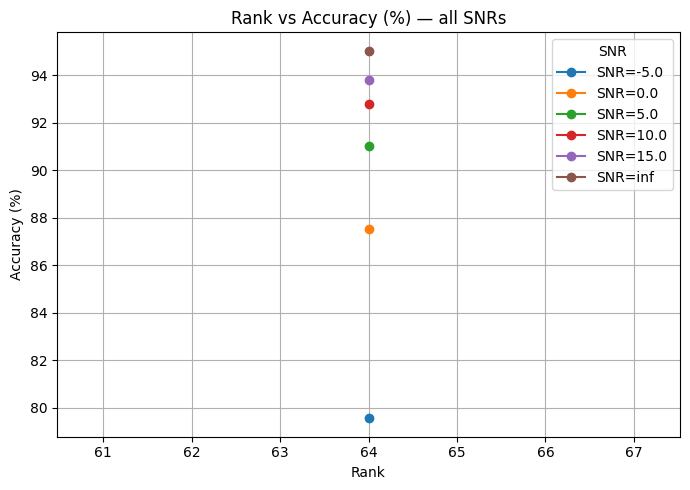


=== Minimum rank to reach acc/max(acc) ≥ 0.95 (acc_all) ===
 snr_eval  min_rank_for_ratio  ratio_target  achieved_ratio_at_min_rank  acc_at_min_rank   max_acc
     -5.0                  64          0.95                         1.0        79.560724 79.560724
      0.0                  64          0.95                         1.0        87.537837 87.537837
      5.0                  64          0.95                         1.0        91.018826 91.018826
     10.0                  64          0.95                         1.0        92.809155 92.809155
     15.0                  64          0.95                         1.0        93.802141 93.802141
      inf                  64          0.95                         1.0        95.031377 95.031377


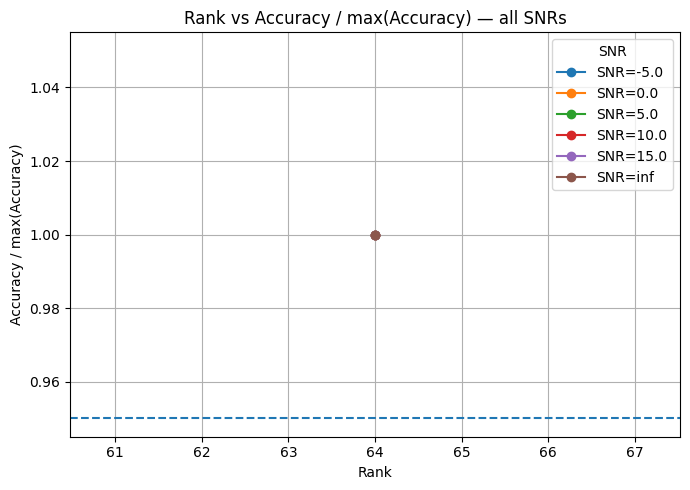

In [ ]:
# Normal accuracy plots
summary, ratio_tbl = plot_rank_vs_acc_per_snr(df, include_silence=True, y_mode="acc",plot_per_snr=False)

# Ratio plots + printed table of min rank per SNR to reach 0.8
summary, ratio_tbl = plot_rank_vs_acc_per_snr(
    df,
    include_silence=True,
    y_mode="ratio",
    ratio_target=0.95,
    print_ratio_summary=True,
    plot_per_snr=False,
)

In [ ]:
df.groupby(['snr_eval', 'id'])['rank'].nunique().min()

np.int64(1)

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt


def plot_min_correct_rank_distributions_grid(
    df: pd.DataFrame,
    *,
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    id_col: str = "id",
    normalize: bool = True,
    figsize_per_plot=(5, 4),
    ncols: int = 3,
):
    """
    Grid of plots (one per SNR):
      - histogram of min rank where each sample becomes correct
      - shared x/y limits across all SNR plots
      - overlays mean / median / mode / 95th percentile
      - each subplot has its OWN legend with numeric values
      - x ticks shown on ALL plots and are every other integer
    """

    needed = {snr_col, rank_col, correct_col, id_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # --- keep only rows where prediction is correct ---
    correct_df = df[df[correct_col].astype(bool)]

    # --- min rank where sample becomes correct ---
    min_rank_df = (
        correct_df
        .groupby([snr_col, id_col])[rank_col]
        .min()
        .reset_index(name="min_rank")
    )

    # --- all samples (to detect never-correct) ---
    all_samples = df[[snr_col, id_col]].drop_duplicates()

    per_sample = all_samples.merge(
        min_rank_df,
        on=[snr_col, id_col],
        how="left",
    )

    # -------------------------------------------------
    # PRECOMPUTE GLOBAL AXIS LIMITS
    # -------------------------------------------------
    all_ranks = per_sample["min_rank"].dropna().astype(int)
    if len(all_ranks) == 0:
        return per_sample

    xmin, xmax = int(all_ranks.min()), int(all_ranks.max())

    ymax = 0.0
    for _, sub in per_sample.groupby(snr_col, sort=False):
        ranks = sub["min_rank"].dropna().astype(int)
        if len(ranks) == 0:
            continue
        counts = ranks.value_counts().sort_index()
        y = counts.to_numpy()
        if normalize:
            y = y / y.sum()
        ymax = max(ymax, float(y.max()))

    # -------------------------------------------------
    # GRID SETUP
    # -------------------------------------------------
    snrs = list(per_sample[snr_col].drop_duplicates())
    n_plots = len(snrs)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        sharex=True,
        sharey=True,
    )
    axes = axes.flatten() if n_plots > 1 else [axes]

    xticks = list(range(xmin, xmax + 1, 2))

    # -------------------------------------------------
    # PLOT PER SNR
    # -------------------------------------------------
    for ax, snr in zip(axes, snrs):
        sub = per_sample[per_sample[snr_col] == snr]
        ranks = sub["min_rank"].dropna().astype(int)

        total = len(sub)
        never = int(sub["min_rank"].isna().sum())
        never_pct = 100.0 * never / total if total else 0.0

        if len(ranks) > 0:
            counts = ranks.value_counts().sort_index()
            x = counts.index.to_numpy()
            y = counts.to_numpy()

            if normalize:
                y = y / y.sum()

            ax.bar(x, y)

            # ---- statistics ----
            mean_rank = float(ranks.mean())
            median_rank = float(ranks.median())
            mode_rank = int(ranks.mode().iloc[0])
            p95_rank = float(ranks.quantile(0.95))

            ax.axvline(mean_rank, linestyle="--", linewidth=2,
                       label=f"Mean = {mean_rank:.2f}",color="C1")
            ax.axvline(median_rank, linestyle="-", linewidth=2,
                       label=f"Median = {median_rank:.2f}", color="C2")
            ax.axvline(mode_rank, linestyle=":", linewidth=2,
                       label=f"Mode = {mode_rank}",color="C3")
            ax.axvline(p95_rank, linestyle="-.", linewidth=2,
                       label=f"P95 = {p95_rank:.2f}",color="C4")

            ax.legend(frameon=False, fontsize=9)

        else:
            ax.text(0.5, 0.5, "No correct samples",
                    ha="center", va="center", transform=ax.transAxes)

        ax.set_title(
            f"SNR={snr}\nnever: {never}/{total} ({never_pct:.1f}%)",
            fontsize=10,
        )

        ax.set_xlim(xmin - 0.5, xmax + 0.5)
        ax.set_ylim(0, ymax * 1.05)
        ax.grid(axis="y", alpha=0.3)

        # ---- force x ticks on all plots ----
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks, rotation=90)
        ax.tick_params(axis="x", labelbottom=True)

    # hide unused axes
    for ax in axes[n_plots:]:
        ax.axis("off")

    # -------------------------------------------------
    # GLOBAL LABELS
    # -------------------------------------------------
    fig.text(0.5, 0.04, "Minimum rank where sample is correct", ha="center")
    fig.text(
        0.04,
        0.5,
        "Probability" if normalize else "Count",
        va="center",
        rotation="vertical",
    )

    fig.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()

    return per_sample



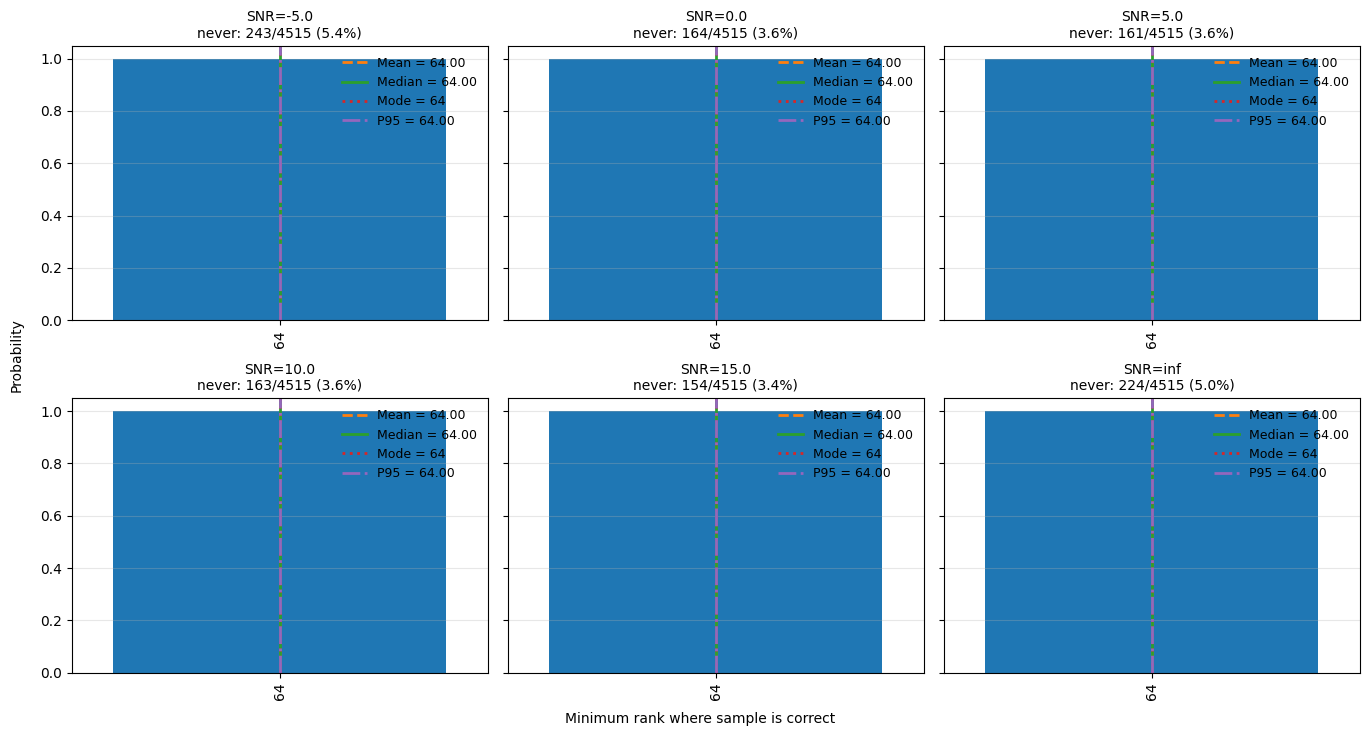

In [ ]:
per_sample_min_correct_rank = plot_min_correct_rank_distributions_grid(
    comb_1_df,
    normalize=True,
)

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt


def plot_min_correct_rank_distributions_grid_extra(
    df: pd.DataFrame,
    *,
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    id_col: str = "id",
    normalize: bool = True,
    figsize_per_plot=(5, 4),
    ncols: int = 3,
    print_post_summary: bool = True,
):
    """
    Grid of plots (one per SNR):
      - histogram of min rank where each sample becomes correct
      - shared x/y limits across all SNR plots
      - overlays mean / median / mode / 95th percentile
      - each subplot has its OWN legend with numeric values
      - x ticks shown on ALL plots and are every other integer

    After plotting, prints a per-SNR summary comparing:
      - oracle(any-rank) accuracy: sample is correct if correct at ANY rank
      - full-rank accuracy: correct at max rank (max(rank_col) in df)
      - delta = oracle - full_rank

    Returns
    -------
    per_sample : pd.DataFrame
        One row per (snr,id) with min_rank (NaN if never correct)
    acc_summary : pd.DataFrame
        Per SNR: acc_any, acc_full_rank, delta, max_rank, n_samples
    """

    needed = {snr_col, rank_col, correct_col, id_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    work = df.copy()
    work[rank_col] = pd.to_numeric(work[rank_col])
    work[correct_col] = work[correct_col].astype(bool)

    # -------------------------
    # Per-sample min-rank table
    # -------------------------
    correct_df = work[work[correct_col]]

    min_rank_df = (
        correct_df
        .groupby([snr_col, id_col])[rank_col]
        .min()
        .reset_index(name="min_rank")
    )

    all_samples = work[[snr_col, id_col]].drop_duplicates()

    per_sample = all_samples.merge(
        min_rank_df,
        on=[snr_col, id_col],
        how="left",
    )

    # -------------------------
    # Global axis limits
    # -------------------------
    all_ranks = per_sample["min_rank"].dropna().astype(int)
    if len(all_ranks) == 0:
        # still compute and print acc summary
        max_rank = int(work[rank_col].max())
        acc_summary = _acc_any_vs_full_rank_summary(
            work,
            snr_col=snr_col,
            id_col=id_col,
            rank_col=rank_col,
            correct_col=correct_col,
            max_rank=max_rank,
        )
        if print_post_summary:
            print("\n=== Oracle(any-rank) vs full-rank accuracy (no correct samples at any SNR) ===")
            print(acc_summary.to_string(index=False))
        return per_sample, acc_summary

    xmin, xmax = int(all_ranks.min()), int(all_ranks.max())

    ymax = 0.0
    for _, sub in per_sample.groupby(snr_col, sort=False):
        ranks = sub["min_rank"].dropna().astype(int)
        if len(ranks) == 0:
            continue
        counts = ranks.value_counts().sort_index()
        y = counts.to_numpy()
        if normalize:
            y = y / y.sum()
        ymax = max(ymax, float(y.max()))

    # -------------------------
    # Grid setup
    # -------------------------
    snrs = list(per_sample[snr_col].drop_duplicates())
    n_plots = len(snrs)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        sharex=True,
        sharey=True,
    )
    axes = axes.flatten() if n_plots > 1 else [axes]

    xticks = list(range(xmin, xmax + 1, 2))

    # -------------------------
    # Plot per SNR
    # -------------------------
    for ax, snr in zip(axes, snrs):
        sub = per_sample[per_sample[snr_col] == snr]
        ranks = sub["min_rank"].dropna().astype(int)

        total = len(sub)
        never = int(sub["min_rank"].isna().sum())
        never_pct = 100.0 * never / total if total else 0.0

        if len(ranks) > 0:
            counts = ranks.value_counts().sort_index()
            x = counts.index.to_numpy()
            y = counts.to_numpy()

            if normalize:
                y = y / y.sum()

            ax.bar(x, y)

            # stats
            mean_rank = float(ranks.mean())
            median_rank = float(ranks.median())
            mode_rank = int(ranks.mode().iloc[0])
            p95_rank = float(ranks.quantile(0.95))

            ax.axvline(mean_rank, linestyle="--", linewidth=2, label=f"Mean = {mean_rank:.2f}",color="C1")
            ax.axvline(median_rank, linestyle="-", linewidth=2, label=f"Median = {median_rank:.2f}",color="C2")
            ax.axvline(mode_rank, linestyle=":", linewidth=2, label=f"Mode = {mode_rank}",color="C3")
            ax.axvline(p95_rank, linestyle="-.", linewidth=2, label=f"P95 = {p95_rank:.2f}",color="C4")

            ax.legend(frameon=False, fontsize=9)
        else:
            ax.text(0.5, 0.5, "No correct samples", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(
            f"SNR={snr}\nnever: {never}/{total} ({never_pct:.1f}%)",
            fontsize=10,
        )

        ax.set_xlim(xmin - 0.5, xmax + 0.5)
        ax.set_ylim(0, ymax * 1.05)
        ax.grid(axis="y", alpha=0.3)

        # force x ticks on all plots
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks, rotation=90)
        ax.tick_params(axis="x", labelbottom=True)

    # hide unused axes
    for ax in axes[n_plots:]:
        ax.axis("off")

    # global labels
    fig.text(0.5, 0.04, "Minimum rank where sample is correct", ha="center")
    fig.text(
        0.04,
        0.5,
        "Probability" if normalize else "Count",
        va="center",
        rotation="vertical",
    )

    fig.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()

    # -------------------------
    # Post summary: acc_any vs acc_full(max rank)
    # -------------------------
    max_rank = int(work[rank_col].max())
    acc_summary = _acc_any_vs_full_rank_summary(
        work,
        snr_col=snr_col,
        id_col=id_col,
        rank_col=rank_col,
        correct_col=correct_col,
        max_rank=max_rank,
    )

    if print_post_summary:
        print("\n=== Oracle(any-rank) vs full-rank accuracy ===")
        print(acc_summary.to_string(index=False))

    return per_sample, acc_summary


def _acc_any_vs_full_rank_summary(
    work: pd.DataFrame,
    *,
    snr_col: str,
    id_col: str,
    rank_col: str,
    correct_col: str,
    max_rank: int,
) -> pd.DataFrame:
    # one row per (snr,id): ever correct at any rank?
    any_correct = (
        work.groupby([snr_col, id_col], sort=False)[correct_col]
            .any()
            .reset_index(name="any_correct")
    )

    # one row per (snr,id): correct at max rank?
    full = (
        work[work[rank_col] == max_rank]
        .groupby([snr_col, id_col], sort=False)[correct_col]
        .any()
        .reset_index(name="correct_at_max_rank")
    )

    merged = any_correct.merge(full, on=[snr_col, id_col], how="left")
    merged["correct_at_max_rank"] = merged["correct_at_max_rank"].fillna(False)

    out = (
        merged.groupby(snr_col, sort=False)
        .agg(
            n_samples=(id_col, "count"),
            acc_any=("any_correct", "mean"),
            acc_full_rank=("correct_at_max_rank", "mean"),
        )
        .reset_index()
    )

    out["acc_any"] = out["acc_any"] * 100
    out["acc_full_rank"] = out["acc_full_rank"] * 100
    out["delta_any_minus_full"] = out["acc_any"] - out["acc_full_rank"]
    out["max_rank"] = max_rank

    # nice column order
    out = out[[snr_col, "n_samples", "max_rank", "acc_any", "acc_full_rank", "delta_any_minus_full"]]
    return out


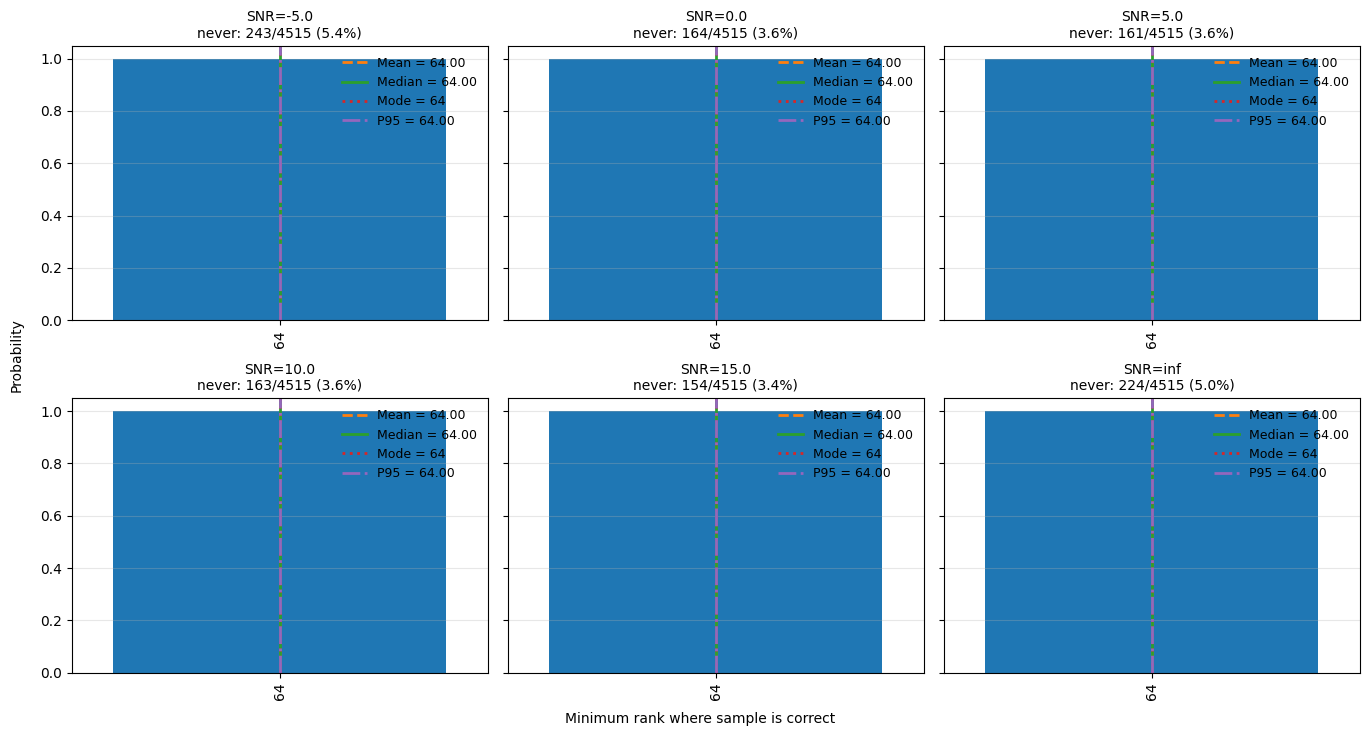


=== Oracle(any-rank) vs full-rank accuracy ===
 snr_eval  n_samples  max_rank   acc_any  acc_full_rank  delta_any_minus_full
     -5.0       4515        64 94.617940      94.617940                   0.0
      0.0       4515        64 96.367663      96.367663                   0.0
      5.0       4515        64 96.434109      96.434109                   0.0
     10.0       4515        64 96.389812      96.389812                   0.0
     15.0       4515        64 96.589147      96.589147                   0.0
      inf       4515        64 95.038760      95.038760                   0.0


In [ ]:
per_sample, acc_summary = plot_min_correct_rank_distributions_grid_extra(
    comb_1_df,
    snr_col="snr_eval",
    rank_col="rank",
    correct_col="correct",
    id_col="id",
    normalize=True,
    ncols=3,                 # e.g. 2x3 grid for 6 SNR values
    figsize_per_plot=(5, 4),
    print_post_summary=True, # prints the oracle vs full-rank table
)

In [ ]:
bad = (
    comb_1_df
    .groupby(['snr_eval', 'id'])['target']
    .nunique()
)
print("Bad IDs:", (bad > 1).sum())

Bad IDs: 0


In [ ]:
def inspect_sample(df, snr, sample_id):
    sub = (
        df[(df["snr_eval"] == snr) & (df["id"] == sample_id)]
        .sort_values("rank")
    )
    return sub[["rank", "correct"]]

inspect_sample(comb_1_df, -5.0, 32)

,rank,correct
32,64,False
27122,64,True
54212,64,True
81302,64,True
108392,64,True
135482,64,True


In [ ]:
import pandas as pd
import numpy as np

def diagnose_non_monotonic_correctness(
    df: pd.DataFrame,
    *,
    snr_col="snr_eval",
    id_col="id",
    rank_col="rank",
    correct_col="correct",
):
    work = df.copy()
    work[rank_col] = pd.to_numeric(work[rank_col])
    work[correct_col] = work[correct_col].astype(bool)

    # wide matrix: rows=(snr,id), cols=rank, values=correct
    mat = (
        work.pivot_table(
            index=[snr_col, id_col],
            columns=rank_col,
            values=correct_col,
            aggfunc="first",
        )
        .sort_index(axis=1)
    )

    ranks = mat.columns.to_numpy()
    if len(ranks) < 2:
        raise ValueError("Need at least 2 ranks to diagnose monotonicity.")

    # forward monotone check: once correct, should remain correct
    arr = mat.to_numpy(dtype=float)  # NaN if missing
    # treat NaN as missing; we'll mask them out
    valid = ~np.isnan(arr)
    arr_bool = np.where(valid, arr > 0.5, False)

    # For each row, compute if there exists i<j with correct[i]=1 and correct[j]=0
    # A simple way: for each position j, check if any earlier correct and current incorrect
    prefix_any_correct = np.maximum.accumulate(arr_bool, axis=1)
    violation_matrix = prefix_any_correct & (~arr_bool)  # True where a violation occurs
    # But ignore positions where current is missing
    violation_matrix = violation_matrix & valid

    has_violation = violation_matrix.any(axis=1)

    # Wrong at max rank but correct at some other rank
    max_rank = ranks.max()
    is_correct_at_max = mat[max_rank].fillna(False).astype(bool)
    is_correct_any = mat.fillna(False).any(axis=1)
    wrong_at_max_but_correct_somewhere = (~is_correct_at_max) & (is_correct_any)

    summary = pd.DataFrame({
        "n_samples": mat.shape[0],
        "n_with_any_violation": has_violation.sum(),
        "pct_with_any_violation": 100 * has_violation.mean(),
        "n_wrong_at_max_but_correct_somewhere": wrong_at_max_but_correct_somewhere.sum(),
        "pct_wrong_at_max_but_correct_somewhere": 100 * wrong_at_max_but_correct_somewhere.mean(),
        "max_rank": max_rank,
    }, index=["ALL"])

    # Per SNR breakdown
    idx = mat.index
    snrs = idx.get_level_values(0)
    per_snr = []
    for snr in snrs.unique():
        mask = (snrs == snr)
        per_snr.append({
            snr_col: snr,
            "n_samples": int(mask.sum()),
            "pct_with_any_violation": float(has_violation[mask].mean() * 100),
            "pct_wrong_at_max_but_correct_somewhere": float(wrong_at_max_but_correct_somewhere[mask].mean() * 100),
        })
    per_snr = pd.DataFrame(per_snr).sort_values(snr_col)

    # Return some example IDs to inspect
    viol_index = mat.index[has_violation]
    weird_index = mat.index[wrong_at_max_but_correct_somewhere]

    examples = {
        "violation_examples": viol_index[:20].tolist(),
        "wrong_at_max_but_correct_somewhere_examples": weird_index[:20].tolist(),
    }

    return mat, summary, per_snr, examples


In [ ]:
mat, summary, per_snr, examples = diagnose_non_monotonic_correctness(comb_1_df)
print(summary.to_string(index=False))
print(per_snr.to_string(index=False))
print(examples)

ValueError: Need at least 2 ranks to diagnose monotonicity.

In [ ]:
def show_sample_correctness_curve(mat, snr, sample_id, *, snr_col="snr_eval", id_col="id"):
    row = mat.loc[(snr, sample_id)]
    print(row.astype("boolean"))  # True/False/NA

In [ ]:
snr, sid = examples["wrong_at_max_but_correct_somewhere_examples"][1]
show_sample_correctness_curve(mat, snr, sid)

rank
1     False
2     False
3     False
4     False
5     False
      ...  
60    False
61    False
62    False
63    False
64    False
Name: (-5.0, 8), Length: 64, dtype: boolean


In [ ]:
import numpy as np
import pandas as pd


def compute_flip_counts(
    df: pd.DataFrame,
    *,
    snr_col="snr_eval",
    id_col="id",
    rank_col="rank",
    correct_col="correct",
):
    """
    Returns one row per (snr_eval, id) with:
      - n_flips: number of correctness flips across ranks
      - n_ranks: number of evaluated ranks
      - ever_correct
      - correct_at_max_rank
    """

    work = df.copy()
    work[rank_col] = pd.to_numeric(work[rank_col])
    work[correct_col] = work[correct_col].astype(int)

    rows = []

    for (snr, sid), sub in work.groupby([snr_col, id_col], sort=False):
        sub = sub.sort_values(rank_col)

        y = sub[correct_col].to_numpy()

        # count adjacent flips
        n_flips = int(np.sum(y[1:] != y[:-1]))

        rows.append({
            snr_col: snr,
            id_col: sid,
            "n_flips": n_flips,
            "n_ranks": len(y),
            "ever_correct": bool(y.any()),
            "correct_at_max_rank": bool(y[-1]),
        })

    return pd.DataFrame(rows)

In [ ]:
flips_df = compute_flip_counts(comb_1_df)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


import numpy as np
import matplotlib.pyplot as plt


def plot_flip_histograms(
    flips_df,
    *,
    snr_col="snr_eval",
    flip_col="n_flips",
    max_flips=20,        # last bin collects >= max_flips
    normalize=True,      # probability instead of count
    figsize=(6, 4),
):
    snrs = sorted(flips_df[snr_col].unique())

    # fixed bins: 0,1,2,...,max_flips
    bins = np.arange(0, max_flips + 1)

    # ---- precompute histograms and global y-limit ----
    histograms = {}
    global_max_y = 0.0

    for snr in snrs:
        vals = flips_df.loc[flips_df[snr_col] == snr, flip_col]
        vals = vals.clip(upper=max_flips)

        counts = (
            vals.value_counts()
                .reindex(bins, fill_value=0)
                .sort_index()
        )

        if normalize:
            counts = counts / counts.sum()

        histograms[snr] = counts
        global_max_y = max(global_max_y, counts.max())

    # ---- plot ----
    for snr in snrs:
        counts = histograms[snr]

        plt.figure(figsize=figsize)
        plt.bar(bins, counts.values, width=0.9)

        plt.xlim(-0.5, max_flips + 0.5)
        plt.ylim(0, global_max_y * 1.05)

        plt.xticks(bins)
        plt.xlabel("Number of correctness flips across ranks")
        plt.ylabel("Probability" if normalize else "Number of samples")
        plt.title(f"SNR={snr} — flip count distribution")

        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

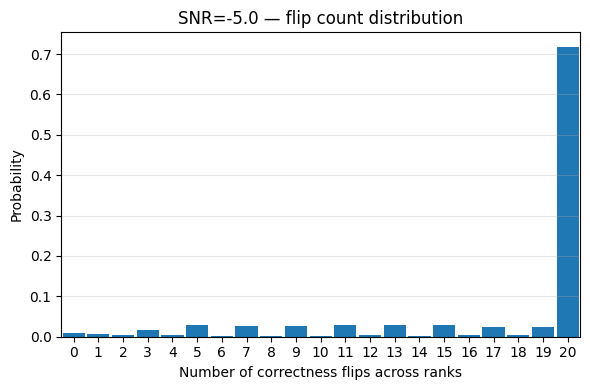

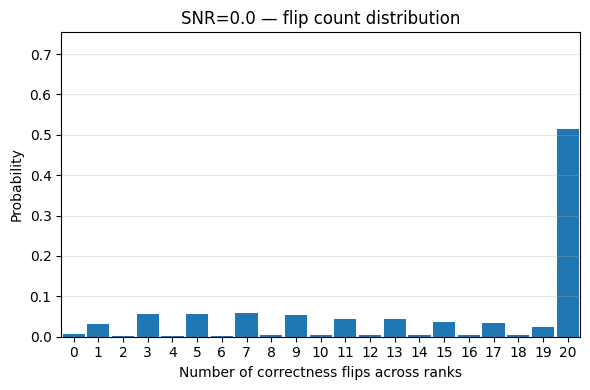

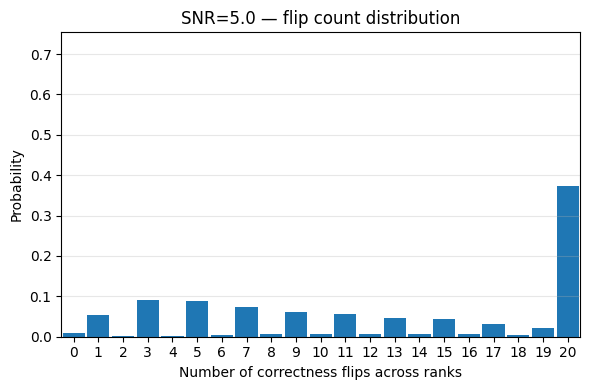

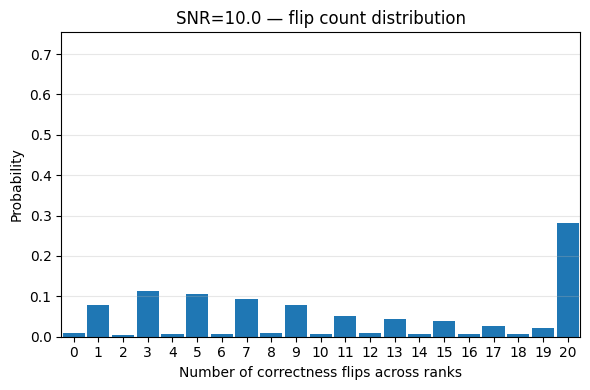

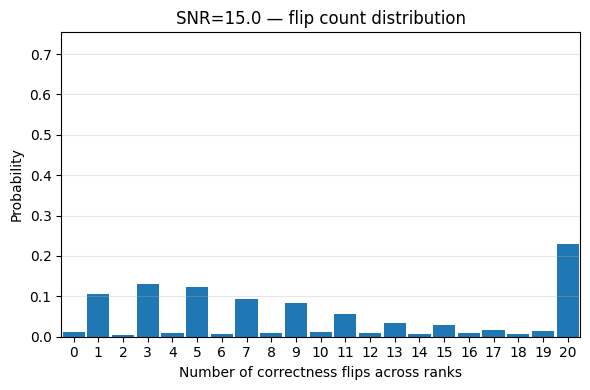

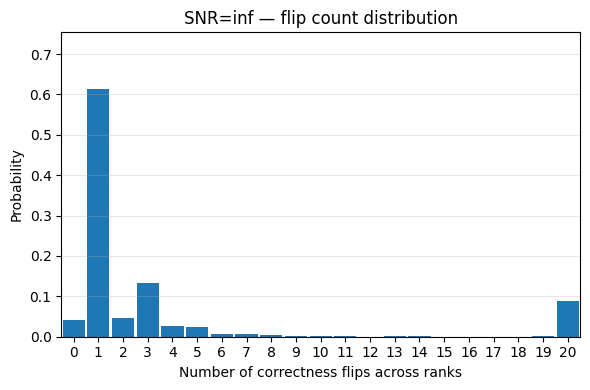

In [ ]:
plot_flip_histograms(flips_df)

In [ ]:
g = (
    comb_1_df
    .assign(is_silence=comb_1_df["label"] == "SILENCE")
    .groupby(["rank", "snr_eval"])
)

acc_all = g["correct"].mean() * 100

acc_non_silence = (
    comb_1_df[comb_1_df["label"] != "SILENCE"]
    .groupby(["rank", "snr_eval"])["correct"]
    .mean()
    * 100
)

summary = (
    pd.concat(
        {
            "acc_all": acc_all,
            "acc_non_silence": acc_non_silence,
        },
        axis=1,
    )
    .assign(acc_diff=lambda df: df["acc_all"] - df["acc_non_silence"])
)

summary

acc_all  acc_non_silence  acc_diff
rank snr_eval                                      
1    -5.0      11.273533        11.572159 -0.298626
      0.0      11.683278        12.022390 -0.339112
      5.0      11.657438        11.993997 -0.336559
      10.0     11.646364        11.981829 -0.335465
      15.0     11.321521        11.624888 -0.303368
...                  ...              ...       ...
64    0.0      87.537837        86.314594  1.223243
      5.0      91.018826        90.139531  0.879295
      10.0     92.809155        92.106758  0.702397
      15.0     93.802141        93.197858  0.604283
      inf      95.031377        94.548552  0.482825

[384 rows x 3 columns]